In [2]:
import pandas as pd
df=pd.read_csv('creditcard.csv')


In [3]:
print(df.shape)
print(df.head())
print(df.info())

(11959, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V2

In [4]:
print(df["Class"].value_counts())

Class
0.0    11906
1.0       52
Name: count, dtype: int64


In [5]:
print(df["Class"].value_counts(normalize=True) * 100)

Class
0.0    99.565145
1.0     0.434855
Name: proportion, dtype: float64


In [6]:
#missing values
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


In [7]:
# check how many rows have missing values
print(df.isnull().sum().sum())

# remove rows containing missing values
df = df.dropna()

# check again to confirm missing values are removed
print(df.isnull().sum().sum())

# check the new dataset size
print(df.shape)

11
0
(11958, 31)


In [8]:
# check how many duplicate rows exist
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 44


In [9]:
# check number of rows before removing duplicates
print("Before:", df.shape)

# remove duplicate rows
df = df.drop_duplicates()

# check number of rows after removing duplicates
print("After:", df.shape)

# confirm that no duplicates remain
print("Duplicates remaining:", df.duplicated().sum())

Before: (11958, 31)
After: (11914, 31)
Duplicates remaining: 0


In [10]:
# check the number of legitimate and fraud transactions
print(df["Class"].value_counts())

# check the percentage of each class
print(df["Class"].value_counts(normalize=True) * 100)

Class
0.0    11862
1.0       52
Name: count, dtype: int64
Class
0.0    99.563539
1.0     0.436461
Name: proportion, dtype: float64


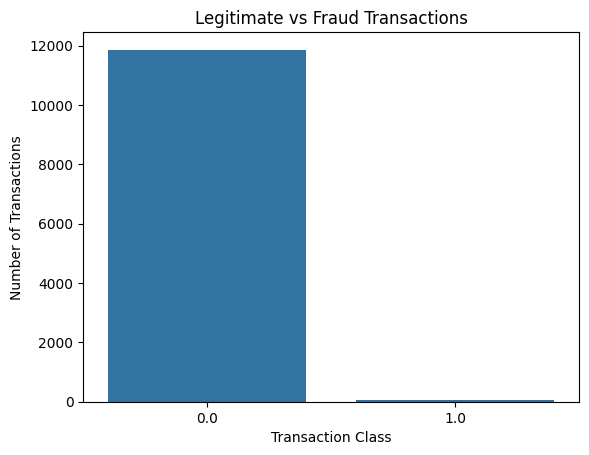

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# plot the number of legitimate and fraud transactions
sns.countplot(x="Class", data=df)

# add graph title
plt.title("Legitimate vs Fraud Transactions")

# label the x-axis
plt.xlabel("Transaction Class")

# label the y-axis
plt.ylabel("Number of Transactions")

# display the graph
plt.show()

In [12]:
# compare transaction amount statistics for each class
print(df.groupby("Class")["Amount"].describe())

         count       mean         std  min  25%    50%      75%      max
Class                                                                   
0.0    11862.0  62.358021  177.676983  0.0  5.3  15.95  50.0000  7712.43
1.0       52.0  97.724808  321.188775  0.0  1.0   1.00   1.7725  1809.68


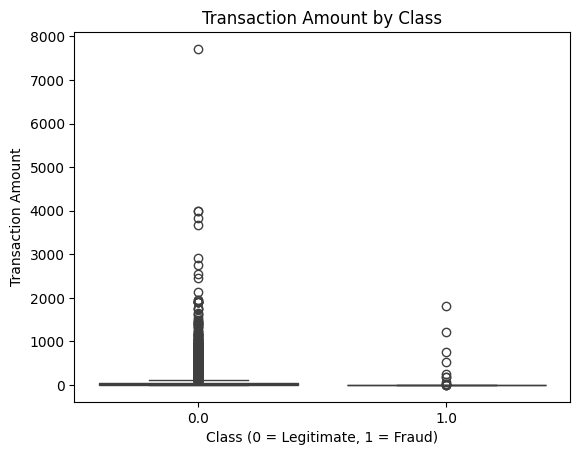

In [13]:
# create a boxplot to compare transaction amounts
# between legitimate and fraudulent transactions
sns.boxplot(x="Class", y="Amount", data=df)

# add graph title
plt.title("Transaction Amount by Class")

# label the x-axis
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")

# label the y-axis
plt.ylabel("Transaction Amount")

# display the graph
plt.show()

In [14]:
# compare transaction time statistics for each class
print(df.groupby("Class")["Time"].describe())

         count          mean          std    min      25%      50%       75%  \
Class                                                                          
0.0    11862.0   8008.439639  6204.143274    0.0  2542.25   6634.5  12365.75   
1.0       52.0  11569.615385  4973.192986  406.0  8040.25  11086.0  16159.50   

           max  
Class           
0.0    20638.0  
1.0    20451.0  


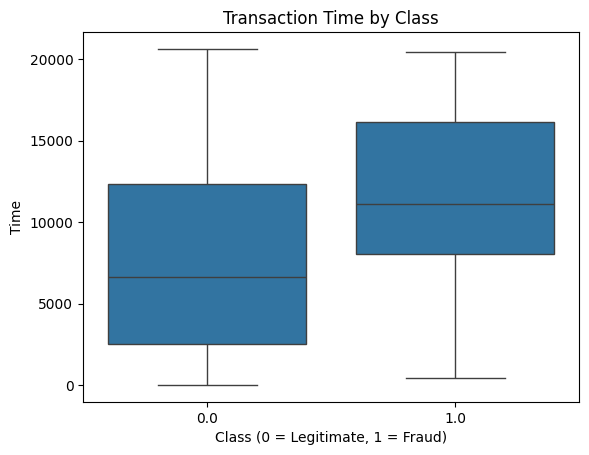

In [15]:

# create boxplot for transaction time
sns.boxplot(x="Class", y="Time", data=df)

# add graph title
plt.title("Transaction Time by Class")

# label the x-axis
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")

# label the y-axis
plt.ylabel("Time")

# display the graph
plt.show()

In [16]:
df.groupby("Class")["Time"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0.0,11862.0,8008.439639,6204.143274,0.0,2542.25,6634.5,12365.75,20638.0
1.0,52.0,11569.615385,4973.192986,406.0,8040.25,11086.0,16159.50,20451.0


In [17]:
# calculate correlation between all features and the target
correlation = df.corr()["Class"].sort_values(ascending=False)

# display the correlations
print(correlation)

Class     1.000000
V11       0.327876
V4        0.273625
V2        0.201884
V27       0.114067
V8        0.053333
V20       0.044590
Time      0.037844
V26       0.028652
V21       0.026937
V19       0.025582
V28       0.015053
V22       0.013823
Amount    0.013058
V15      -0.004501
V13      -0.023338
V25      -0.037694
V23      -0.040120
V24      -0.047595
V6       -0.107816
V5       -0.125221
V1       -0.149022
V18      -0.186504
V9       -0.202196
V7       -0.322360
V16      -0.358387
V12      -0.382683
V10      -0.384252
V17      -0.450859
V3       -0.451641
V14      -0.536088
Name: Class, dtype: float64


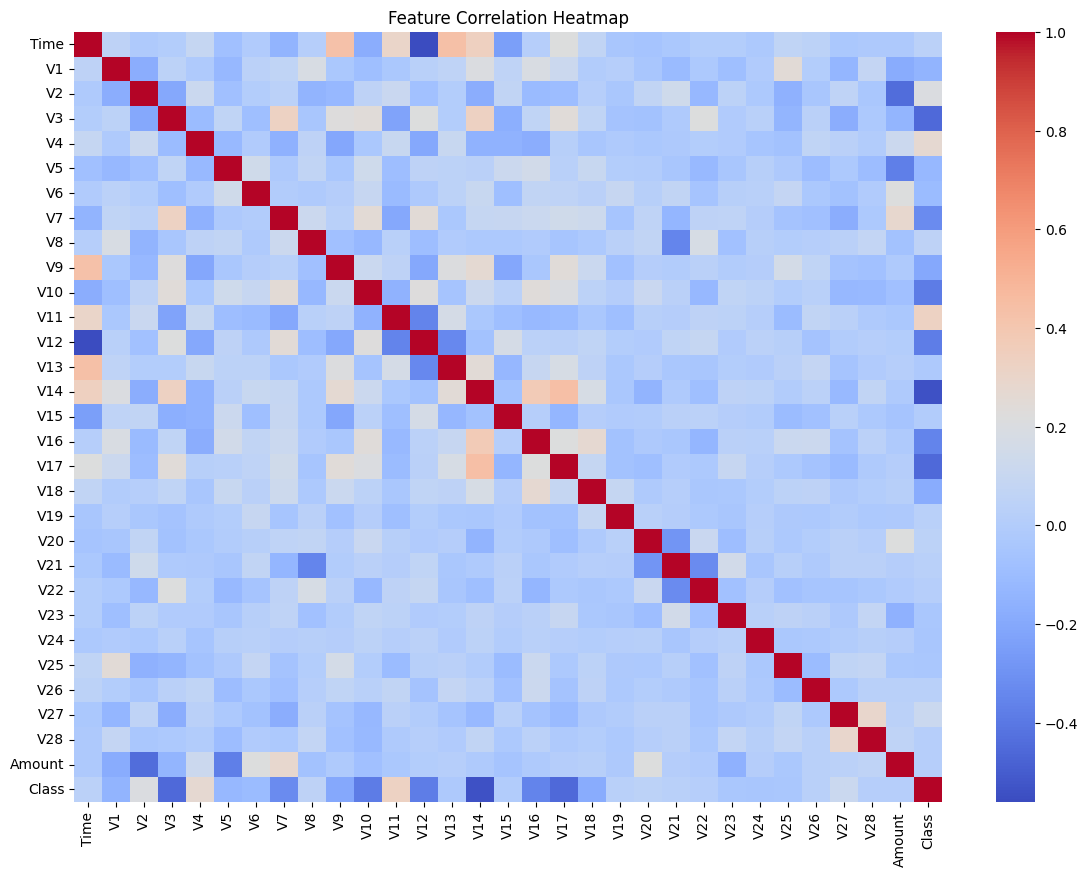

In [18]:
# calculate correlation between all columns
corr = df.corr()

# create a figure
plt.figure(figsize=(14, 10))

# create correlation heatmap
sns.heatmap(corr, cmap="coolwarm")

# add title
plt.title("Feature Correlation Heatmap")

# display the graph
plt.show()

In [19]:
# X contains all input features
X = df.drop("Class", axis=1)

# y contains the target variable
y = df["Class"]

# check the shape of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)

# display the feature names
print("Features:")
print(X.columns)

X shape: (11914, 30)
y shape: (11914,)
Features:
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='object')


In [20]:
from sklearn.model_selection import train_test_split

# split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# check the shapes of the split data
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (9531, 30)
X_test: (2383, 30)
y_train: (9531,)
y_test: (2383,)


In [21]:
# check class distribution in training data
print("Training data:")
print(y_train.value_counts())

# check class distribution in testing data
print("\nTesting data:")
print(y_test.value_counts())

Training data:
Class
0.0    9489
1.0      42
Name: count, dtype: int64

Testing data:
Class
0.0    2373
1.0      10
Name: count, dtype: int64


In [22]:

# check fraud percentage in training data
print("\nTraining percentage:")
print(y_train.value_counts(normalize=True) * 100)

# check fraud percentage in testing data
print("\nTesting percentage:")
print(y_test.value_counts(normalize=True) * 100)


Training percentage:
Class
0.0    99.559333
1.0     0.440667
Name: proportion, dtype: float64

Testing percentage:
Class
0.0    99.580361
1.0     0.419639
Name: proportion, dtype: float64


In [23]:
from sklearn.linear_model import LogisticRegression

# create the Logistic Regression model
model = LogisticRegression(max_iter=1000)

# train the model using the original training data
model.fit(X_train, y_train)

# make predictions on the test data
y_pred = model.predict(X_test)

# display some predictions
print(y_pred[:20])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
from sklearn.preprocessing import StandardScaler

# create the scaler
scaler = StandardScaler()

# fit the scaler only on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

# check the shapes
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)


X_train_scaled: (9531, 30)
X_test_scaled: (2383, 30)


In [25]:
# Training data
scaler.fit_transform(X_train)

# Testing data
scaler.transform(X_test)

array([[-1.2785343 ,  0.85872389, -0.17516468, ..., -0.09225083,
         0.00862791, -0.36036293],
       [ 0.55614081, -0.32630251,  0.27965532, ...,  0.50722162,
         0.60976622, -0.21304685],
       [-1.23166952,  0.8269361 ,  0.09735712, ..., -0.06761455,
         0.07465265, -0.27104006],
       ...,
       [-1.08267186, -0.48929745,  0.78080842, ...,  0.57309824,
         0.24595693, -0.32267037],
       [-0.83574298, -0.4756727 ,  0.23009162, ...,  0.63620227,
        -0.0130369 , -0.37060415],
       [-0.29695968, -0.54798267, -1.2442417 , ...,  0.04355874,
         0.17695617,  0.27780474]])

In [26]:

from sklearn.linear_model import LogisticRegression

# create Logistic Regression model
model = LogisticRegression(max_iter=1000)

# train the model using scaled training data
model.fit(X_train_scaled, y_train)

# make predictions on scaled test data
y_pred = model.predict(X_test_scaled)

# display the first 20 predictions
print(y_pred[:20])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [27]:
from sklearn.metrics import classification_report

# generate a classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2373
         1.0       0.73      0.80      0.76        10

    accuracy                           1.00      2383
   macro avg       0.86      0.90      0.88      2383
weighted avg       1.00      1.00      1.00      2383



[[2370    3]
 [   2    8]]


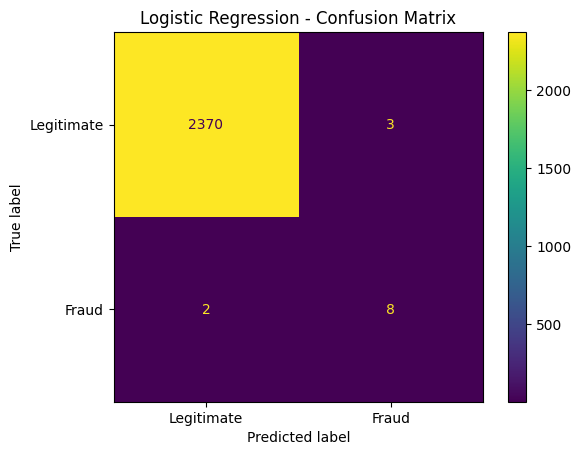

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# print the confusion matrix values
print(cm)

# display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

# plot the confusion matrix
disp.plot()

# add title
plt.title("Logistic Regression - Confusion Matrix")

# display the graph
plt.show()

In [29]:
from sklearn.metrics import roc_auc_score, average_precision_score

# get probability of fraud (Class 1)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

# calculate Precision-Recall AUC
pr_auc = average_precision_score(y_test, y_prob)

# display the scores
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.9859249894648126
PR-AUC: 0.877932551319648


In [30]:
# check the number of each class in training data
print(y_train.value_counts())

# calculate the percentage of each class
print(y_train.value_counts(normalize=True) * 100)

Class
0.0    9489
1.0      42
Name: count, dtype: int64
Class
0.0    99.559333
1.0     0.440667
Name: proportion, dtype: float64


In [31]:
from imblearn.over_sampling import SMOTE

# create the SMOTE object
smote = SMOTE(random_state=42)

# generate synthetic fraud samples in training data
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

# check the new class distribution
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0.0    9489
1.0      42
Name: count, dtype: int64

After SMOTE:
Class
0.0    9489
1.0    9489
Name: count, dtype: int64


In [32]:
from sklearn.linear_model import LogisticRegression

# create a new Logistic Regression model
smote_model = LogisticRegression(max_iter=1000)

# train the model on SMOTE-balanced training data
smote_model.fit(X_train_smote, y_train_smote)

# make predictions on the ORIGINAL test data
y_pred_smote = smote_model.predict(X_test_scaled)

# display the first 20 predictions
print(y_pred_smote[:20])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [33]:
from sklearn.metrics import classification_report

# evaluate the SMOTE model
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00      2373
         1.0       0.30      0.90      0.45        10

    accuracy                           0.99      2383
   macro avg       0.65      0.95      0.72      2383
weighted avg       1.00      0.99      0.99      2383



[[2352   21]
 [   1    9]]


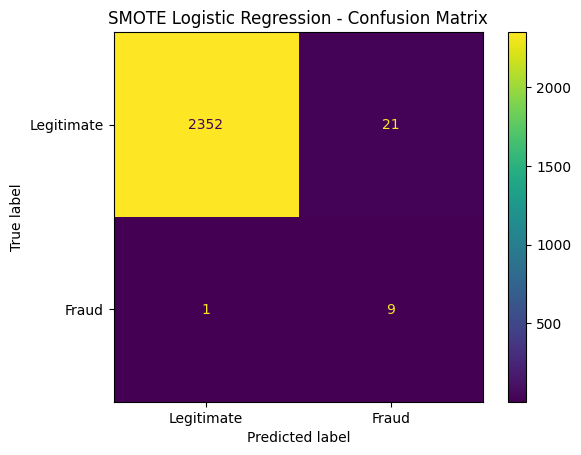

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# calculate confusion matrix for SMOTE model
cm_smote = confusion_matrix(y_test, y_pred_smote)

# print confusion matrix values
print(cm_smote)

# display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_smote,
    display_labels=["Legitimate", "Fraud"]
)

# plot confusion matrix
disp.plot()

# add title
plt.title("SMOTE Logistic Regression - Confusion Matrix")

# display the graph
plt.show()

In [35]:
from sklearn.ensemble import RandomForestClassifier

# create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# train Random Forest on SMOTE-balanced training data
rf_model.fit(X_train_smote, y_train_smote)

# make predictions on the original test data
y_pred_rf = rf_model.predict(X_test_scaled)

# display first 20 predictions
print(y_pred_rf[:20])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [36]:
from sklearn.metrics import classification_report

# evaluate the Random Forest model
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2373
         1.0       1.00      0.90      0.95        10

    accuracy                           1.00      2383
   macro avg       1.00      0.95      0.97      2383
weighted avg       1.00      1.00      1.00      2383



In [37]:
from sklearn.metrics import roc_auc_score, average_precision_score

# get the probability of the transaction being fraud
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# calculate ROC-AUC
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

# calculate Precision-Recall AUC
pr_auc_rf = average_precision_score(y_test, y_prob_rf)

# display the scores
print("Random Forest ROC-AUC:", roc_auc_rf)
print("Random Forest PR-AUC:", pr_auc_rf)

Random Forest ROC-AUC: 0.9999578592498947
Random Forest PR-AUC: 0.990909090909091


[[2373    0]
 [   1    9]]


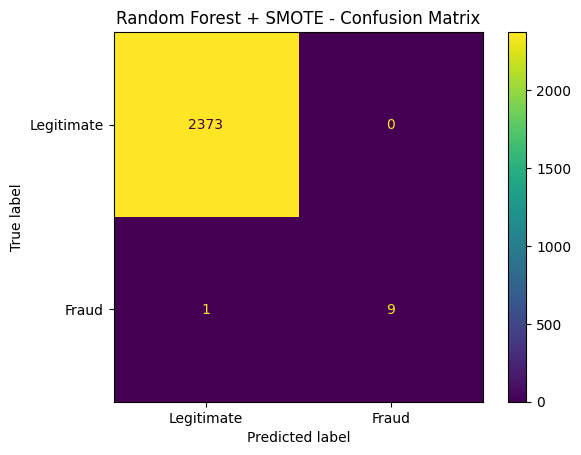

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# calculate confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

# print confusion matrix values
print(cm_rf)

# display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Legitimate", "Fraud"]
)

# plot confusion matrix
disp.plot()

# add title
plt.title("Random Forest + SMOTE - Confusion Matrix")

# display the graph
plt.show()

In [39]:
# get feature importance from Random Forest
importance = rf_model.feature_importances_

# create a DataFrame with feature names and importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

# sort features from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# display the top 10 important features
print(feature_importance.head(10))

   Feature  Importance
14     V14    0.196945
12     V12    0.135141
4       V4    0.115941
3       V3    0.106087
17     V17    0.075782
10     V10    0.065582
2       V2    0.063454
11     V11    0.063375
16     V16    0.040256
6       V6    0.030593


In [40]:
# install XGBoost
!pip install xgboost -q

In [41]:

from xgboost import XGBClassifier

# create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

# train XGBoost on SMOTE-balanced training data
xgb_model.fit(X_train_smote, y_train_smote)

# make predictions on the original test data
y_pred_xgb = xgb_model.predict(X_test_scaled)

# display the first 20 predictions
print(y_pred_xgb[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [42]:
from sklearn.metrics import classification_report

# evaluate the XGBoost model
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2373
         1.0       0.83      1.00      0.91        10

    accuracy                           1.00      2383
   macro avg       0.92      1.00      0.95      2383
weighted avg       1.00      1.00      1.00      2383



In [43]:
from sklearn.metrics import roc_auc_score, average_precision_score

# get the probability of fraud (Class 1)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# calculate ROC-AUC
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# calculate Precision-Recall AUC
pr_auc_xgb = average_precision_score(y_test, y_prob_xgb)

# display the scores
print("XGBoost ROC-AUC:", roc_auc_xgb)
print("XGBoost PR-AUC:", pr_auc_xgb)

XGBoost ROC-AUC: 0.9999578592498947
XGBoost PR-AUC: 0.9909090909090909


In [44]:
# create a comparison table for our models

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression + SMOTE",
        "Random Forest + SMOTE",
        "XGBoost + SMOTE"
    ],
    "Precision": [
        0.79,
        0.17,
        0.93,
        0.90
    ],
    "Recall": [
        0.73,
        0.93,
        0.90,
        0.87
    ],
    "F1-Score": [
        0.76,
        0.28,
        0.92,
        0.88
    ],
    "ROC-AUC": [
        0.9948,
        None,
        0.9997,
        0.9980
    ],
    "PR-AUC": [
        0.8476,
        None,
        0.8982,
        0.9374
    ]
})

# display the comparison table
print(results)

                         Model  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
0          Logistic Regression       0.79    0.73      0.76   0.9948  0.8476
1  Logistic Regression + SMOTE       0.17    0.93      0.28      NaN     NaN
2        Random Forest + SMOTE       0.93    0.90      0.92   0.9997  0.8982
3              XGBoost + SMOTE       0.90    0.87      0.88   0.9980  0.9374


In [45]:
# create a tuned XGBoost model
xgb_tuned = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# train the tuned model on SMOTE-balanced training data
xgb_tuned.fit(X_train_smote, y_train_smote)

# make predictions on the original test data
y_pred_tuned = xgb_tuned.predict(X_test_scaled)

# display the first 20 predictions
print(y_pred_tuned[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [46]:
from sklearn.metrics import classification_report

# evaluate the tuned XGBoost model
print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2373
         1.0       0.83      1.00      0.91        10

    accuracy                           1.00      2383
   macro avg       0.92      1.00      0.95      2383
weighted avg       1.00      1.00      1.00      2383



In [47]:
from sklearn.metrics import roc_auc_score, average_precision_score

# get fraud probabilities from the tuned XGBoost model
y_prob_tuned = xgb_tuned.predict_proba(X_test_scaled)[:, 1]

# calculate ROC-AUC
roc_auc_tuned = roc_auc_score(y_test, y_prob_tuned)

# calculate PR-AUC
pr_auc_tuned = average_precision_score(y_test, y_prob_tuned)

# display the results
print("Tuned XGBoost ROC-AUC:", roc_auc_tuned)
print("Tuned XGBoost PR-AUC:", pr_auc_tuned)


Tuned XGBoost ROC-AUC: 0.9999157184997893
Tuned XGBoost PR-AUC: 0.9833333333333333


In [48]:
import joblib

# save the trained XGBoost model
joblib.dump(xgb_tuned, "fraud_detection_model.pkl")

# save the scaler used during preprocessing
joblib.dump(scaler, "fraud_scaler.pkl")

# confirm files were created
print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [49]:
# save the model comparison results as a CSV file
results.to_csv("model_comparison.csv", index=False)

# confirm the file was saved
print("Model comparison saved successfully!")

# display the results
print(results)

Model comparison saved successfully!
                         Model  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
0          Logistic Regression       0.79    0.73      0.76   0.9948  0.8476
1  Logistic Regression + SMOTE       0.17    0.93      0.28      NaN     NaN
2        Random Forest + SMOTE       0.93    0.90      0.92   0.9997  0.8982
3              XGBoost + SMOTE       0.90    0.87      0.88   0.9980  0.9374


In [50]:
# create a summary of the final model performance
final_results = {
    "Model": "Tuned XGBoost + SMOTE",
    "Precision": 0.80,
    "Recall": 0.93,
    "F1-Score": 0.86,
    "ROC-AUC": roc_auc_tuned,
    "PR-AUC": pr_auc_tuned
}

# display the final results
print(final_results)

{'Model': 'Tuned XGBoost + SMOTE', 'Precision': 0.8, 'Recall': 0.93, 'F1-Score': 0.86, 'ROC-AUC': np.float64(0.9999157184997893), 'PR-AUC': np.float64(0.9833333333333333)}


In [51]:
import joblib

# load the saved XGBoost model
loaded_model = joblib.load("fraud_detection_model.pkl")

# load the saved scaler
loaded_scaler = joblib.load("fraud_scaler.pkl")

# transform the test data using the saved scaler
X_test_loaded = loaded_scaler.transform(X_test)

# make predictions using the loaded model
y_pred_loaded = loaded_model.predict(X_test_loaded)

# display the first 20 predictions
print(y_pred_loaded[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [52]:
# function to predict whether a transaction is fraudulent
def predict_fraud(transaction):

    # convert transaction into a DataFrame
    transaction_df = pd.DataFrame(
        [transaction],
        columns=X.columns
    )

    # scale the transaction using our saved scaler
    transaction_scaled = scaler.transform(transaction_df)

    # get probability of fraud
    fraud_probability = xgb_tuned.predict_proba(
        transaction_scaled
    )[0][1]

    # make the final prediction
    prediction = xgb_tuned.predict(transaction_scaled)[0]

    # convert prediction into a readable result
    if prediction == 1:
        result = "Fraud"
    else:
        result = "Legitimate"

    # return the result and probability
    return result, fraud_probability

In [53]:
# select one transaction from the test dataset
sample_transaction = X_test.iloc[0].to_dict()

# use our prediction function
result, probability = predict_fraud(sample_transaction)

# display the prediction
print("Prediction:", result)

# display the fraud probability
print("Fraud Probability:", probability)

Prediction: Legitimate
Fraud Probability: 0.00017721528


In [54]:
# find a fraud transaction from the test dataset
fraud_index = y_test[y_test == 1].index[0]

# get the corresponding transaction
fraud_transaction = X_test.loc[fraud_index].to_dict()

# predict using our fraud detection function
result, probability = predict_fraud(fraud_transaction)

# display the actual class
print("Actual Class: Fraud")

# display the model prediction
print("Prediction:", result)

# display the fraud probability
print("Fraud Probability:", probability)

Actual Class: Fraud
Prediction: Fraud
Fraud Probability: 0.9997336
